In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
import os

In [2]:
rave_sim_dir = Path('/mnt/d/rave-sim-main/rave-sim-main')
simulations_dir = Path('/mnt/d/rave-sim-main/rave-sim-main/output')
scratch_dir = simulations_dir

In [3]:
sys.path.insert(0, str(rave_sim_dir / "big-wave"))
#print(str(rave_sim_dir / "big-wave"))
import multisim
import config
import util

In [4]:
x=[4,3.5,3,2.5,2]
for ii in x:
    print('output_newa_RC05B_5um_s'+str(ii)+'e-6.txt')
    config_dict = {
        "sim_params": {
            "N": 2**24,
            "dx": 3.1e-10,
            "z_detector":4.6,
            "detector_size": 3e-3,
            "detector_pixel_size_x": 20e-6,
            "detector_pixel_size_y": 1,
            "chunk_size": 512 * 1024 * 1024 // 16,  # use 256MB chunks
        },
        "use_disk_vector": False,
        "save_final_u_vectors": False,
        "dtype": "c8",
        "multisource": {
            "type": "points",
            "energy_range": [10000, 50000],
            "x_range": [-ii*1e-6, ii*1e-6],
            "z": 0.0,
            "nr_source_points": 2,
            "seed": 19260817,
            "spectrum": "/mnt/d/rave-sim-main/rave-sim-main/spectrum/spectrum_25keV.h5",
        },
        "elements": [
            # {
            #     "type": "grating",
            #     "pitch": 10e-6,
            #     "dc": [0.5, 0.5],
            #     "z_start": 0.8,
            #     "thickness": 650e-9,
            #     "nr_steps": 1,
            #     "x_positions": [0.0],
            #     "substrate_thickness": 15 * 1e-6,
            #     "mat_a": ["W", 2.33],
            #     "mat_b": ["Au", 0.0],
            #     "mat_substrate": ["Si", 2.34],
            # },
            {
                "type": "sample",
                "z_start": 0.81,
                # "pixel_size_x": 5 * 1e-6, for precise test
                # "pixel_size_z": 5 * 1e-6,
                "pixel_size_x": 1 * 1e-7, 
                "pixel_size_z": 0.5 * 1e-7,
                "grid_path":"/mnt/d/rave-sim-main/rave-sim-main/grid/5um_RC05B.npy",
                "materials": [["Au", 19.32],["C10H8O4",1.35],["Si",2.33]],
                "x_positions":[0],
            },
        ],
    }
    
    print("N: ", config_dict["sim_params"]["N"])
    sim_path = multisim.setup_simulation(config_dict, Path("."), simulations_dir)
    computed = config.load(Path(sim_path / 'computed.yaml'))
    for i in tqdm(range(config_dict["multisource"]["nr_source_points"])):
        os.system(f"CUDA_VISIBLE_DEVICES=0 /mnt/d/rave-sim-main/rave-sim-main/fast-wave/build-Release/fastwave -s {i} {sim_path}")
    wavefronts = util.load_wavefronts_filtered(sim_path, x_range=(-7.5e-6, 7.5e-6))
    print("nr sources loaded:", len(wavefronts))
    wavef= [result[0] for result in wavefronts]
    wf = np.sum(wavef, axis=0)
    print("nr phase steps:", wf.shape[0])
    print("nr detector pixels:", wf.shape[1])
    sp = config_dict["sim_params"]
    detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
    plt.plot(wf[0])
    from contextlib import redirect_stdout
    with open('output_test_RC05B_5um_s'+str(ii)+'e-6.txt', 'w') as file:
        with redirect_stdout(file):
            for i in range(len(wf[0])):
                print(wf[0][i])
    print(wf[0])

2026-01-19 16:50:16,331 INFO: Setting up simulation
2026-01-19 16:50:16,446 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2026/01/20260119_165016374413


output_newa_RC05B_5um_s4e-6.txt
N:  16777216
3 3


  0%|                                                                                             | 0/2 [00:00<?, ?it/s]

[2026-01-19 16:50:16.599] [info] Running simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/01/20260119_165016374413/00000000


cuda error in operation scale kernel: an illegal memory access was encountered
 50%|██████████████████████████████████████████▌                                          | 1/2 [00:00<00:00,  1.72it/s]

[2026-01-19 16:50:16.955] [info] Simulating optical element 1/1
[2026-01-19 16:50:17.183] [info] Running simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/01/20260119_165016374413/00000001


cuda error in operation scale kernel: an illegal memory access was encountered
100%|█████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.88it/s]

[2026-01-19 16:50:17.446] [info] Simulating optical element 1/1


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/d/rave-sim-main/rave-sim-main/output/2026/01/20260119_165016374413/00000001/detected.npy'

2025-11-02 17:01:38,894 INFO: Setting up simulation


output_newa_RC05B_5um_s4e-6.txt
N:  16777216


2025-11-02 17:01:39,912 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2025/11/20251102_170139323259
  0%|                                                                                            | 0/50 [00:00<?, ?it/s]

[2025-11-02 17:01:40.095] [info] Running simulation /mnt/d/rave-sim-main/rave-sim-main/output/2025/11/20251102_170139323259/00000000
[2025-11-02 17:01:40.483] [info] Simulating optical element 1/1
[2025-11-02 17:01:40.486] [info] PreciseSample info:
[2025-11-02 17:01:40.486] [info]   z_len: 5020, x_len: 450
[2025-11-02 17:01:40.486] [info]   material_deltabetas size: 4
[2025-11-02 17:01:40.486] [info]   Material 0: (0, 0)
[2025-11-02 17:01:40.486] [info]   Material 1: (6.120198604461566e-06, 4.6112087398060007e-07)
[2025-11-02 17:01:40.486] [info]   Material 2: (5.606238036260763e-07, 2.6314382776604566e-10)
[2025-11-02 17:01:40.486] [info]   Material 3: (9.297692872856058e-07, 3.012922749921414e-09)


  2%|█▋                                                                                  | 1/50 [00:31<25:21, 31.06s/it]

...

 98%|█████████████████████████████████████████████████████████████████████████████████▎ | 49/50 [23:15<00:28, 28.36s/it]

[2025-11-02 19:11:33.861] [info] Elapsed time for optical element: 27962.168 ms
[2025-11-02 19:11:33.880] [info] Simulation finished in 30.478080693 seconds
[2025-11-02 19:11:34.106] [info] Running simulation /mnt/d/rave-sim-main/rave-sim-main/output/2025/11/20251102_184817327136/00000049
[2025-11-02 19:11:34.446] [info] Simulating optical element 1/1
[2025-11-02 19:11:34.447] [info] PreciseSample info:
[2025-11-02 19:11:34.447] [info]   z_len: 5020, x_len: 450
[2025-11-02 19:11:34.447] [info]   material_deltabetas size: 4
[2025-11-02 19:11:34.447] [info]   Material 0: (0, 0)
[2025-11-02 19:11:34.447] [info]   Material 1: (2.6155454653143736e-06, 9.821418534960381e-08)
[2025-11-02 19:11:34.447] [info]   Material 2: (2.3930368749579026e-07, 1.0026671913759019e-10)
[2025-11-02 19:11:34.447] [info]   Material 3: (3.9613939176253973e-07, 6.355752457963523e-10)


100%|███████████████████████████████████████████████████████████████████████████████████| 50/50 [23:46<00:00, 28.53s/it]

[2025-11-02 19:12:04.535] [info] Elapsed time for optical element: 27957.55 ms
[2025-11-02 19:12:04.553] [info] Simulation finished in 30.446634246 seconds


nr sources loaded: 50
nr phase steps: 1
nr detector pixels: 150
[4.5761120e-05 4.6988433e-05 4.7297082e-05 4.7148296e-05 4.7153248e-05
 4.7162121e-05 4.7183697e-05 4.7201669e-05 4.7199388e-05 4.7197573e-05
 4.7203834e-05 4.7241578e-05 4.7275182e-05 4.7294940e-05 4.7286961e-05
 4.7292990e-05 4.7270820e-05 4.7241745e-05 4.7213820e-05 4.7209025e-05
 4.7216672e-05 4.7209618e-05 4.7205434e-05 4.7212081e-05 4.7221867e-05
 4.7220146e-05 4.7204445e-05 4.7211699e-05 4.7168549e-05 4.7114921e-05
 4.7082747e-05 4.7072212e-05 4.7079677e-05 4.7089867e-05 4.7096637e-05
 4.7106740e-05 4.7130194e-05 4.7108646e-05 4.7096477e-05 4.7136891e-05
 4.7208559e-05 4.7254744e-05 4.7262733e-05 4.7253932e-05 4.7255635e-05
 4.7251255e-05 4.7203881e-05 4.7180409e-05 4.7177269e-05 4.7148937e-05
 4.7186946e-05 4.7221933e-05 4.7240846e-05 4.7255289e-05 4.7243706e-05
 4.7311427e-05 4.7292378e-05 4.7230773e-05 4.7225822e-05 4.7240177e-05
 4.7225760e-05 4.7378406e-05 4.7375819e-05 4.7445807e-05 4.7970738e-05
 4.6832112e-0

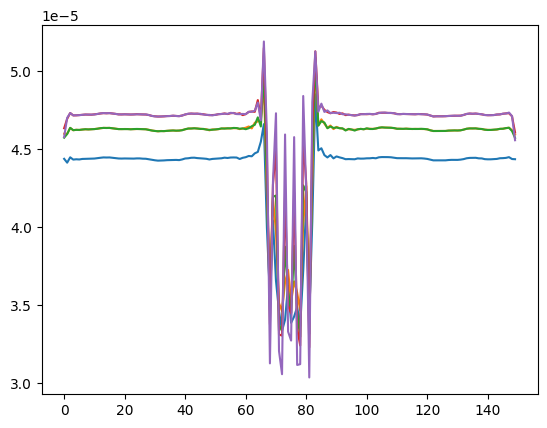

In [4]:
x=[4,3.5,3,2.5,2]
for ii in x:
    print('output_newa_RC05B_5um_s'+str(ii)+'e-6.txt')
    config_dict = {
        "sim_params": {
            "N": 2**24,
            "dx": 3.1e-10,
            "z_detector":4.6,
            "detector_size": 3e-3,
            "detector_pixel_size_x": 20e-6,
            "detector_pixel_size_y": 1,
            "chunk_size": 512 * 1024 * 1024 // 16,  # use 256MB chunks
        },
        "use_disk_vector": False,
        "save_final_u_vectors": False,
        "dtype": "c8",
        "multisource": {
            "type": "points",
            "energy_range": [10000, 50000],
            "x_range": [-ii*1e-6, ii*1e-6],
            "z": 0.0,
            "nr_source_points": 50,
            "seed": 19260817,
            "spectrum": "/mnt/d/rave-sim-main/rave-sim-main/spectrum/spectrum_25keV.h5",
        },
        "elements": [
            # {
            #     "type": "grating",
            #     "pitch": 10e-6,
            #     "dc": [0.5, 0.5],
            #     "z_start": 0.8,
            #     "thickness": 650e-9,
            #     "nr_steps": 1,
            #     "x_positions": [0.0],
            #     "substrate_thickness": 15 * 1e-6,
            #     "mat_a": ["W", 2.33],
            #     "mat_b": ["Au", 0.0],
            #     "mat_substrate": ["Si", 2.34],
            # },
            {
                "type": "sample",
                "z_start": 0.81,
                # "pixel_size_x": 5 * 1e-6, for precise test
                # "pixel_size_z": 5 * 1e-6,
                "pixel_size_x": 1 * 1e-7, 
                "pixel_size_z": 0.5 * 1e-7,
                "grid_path":"/mnt/d/rave-sim-main/rave-sim-main/grid/5um_RC05B.npy",
                "materials": [["Au", 19.32],["C10H8O4",1.35],["Si",2.33]],
                "x_positions":[0],
            },
        ],
    }
    
    print("N: ", config_dict["sim_params"]["N"])
    sim_path = multisim.setup_simulation(config_dict, Path("."), simulations_dir)
    computed = config.load(Path(sim_path / 'computed.yaml'))
    for i in tqdm(range(config_dict["multisource"]["nr_source_points"])):
        os.system(f"CUDA_VISIBLE_DEVICES=0 /mnt/d/rave-sim-main/rave-sim-main/fast-wave/build-Release/fastwave -s {i} {sim_path}")
    wavefronts = util.load_wavefronts_filtered(sim_path, x_range=(-7.5e-6, 7.5e-6))
    print("nr sources loaded:", len(wavefronts))
    wavef= [result[0] for result in wavefronts]
    wf = np.sum(wavef, axis=0)
    print("nr phase steps:", wf.shape[0])
    print("nr detector pixels:", wf.shape[1])
    sp = config_dict["sim_params"]
    detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
    plt.plot(wf[0])
    from contextlib import redirect_stdout
    with open('output_test_RC05B_5um_s'+str(ii)+'e-6.txt', 'w') as file:
        with redirect_stdout(file):
            for i in range(len(wf[0])):
                print(wf[0][i])
    print(wf[0])